# Lab Day 19 - Wiki-Based Flat RAG vs GraphRAG

This notebook implements a small end-to-end GraphRAG experiment using five Wikipedia articles about major AI and technology organizations. The goal is to compare a simple retrieval baseline against a graph-based retrieval approach on the same corpus.

- **Flat RAG baseline**: retrieves the most relevant text chunks using TF-IDF similarity.
- **GraphRAG prototype**: extracts known entities, constructs a knowledge graph with NetworkX, retrieves 2-hop graph context, and prints supporting evidence.

The implementation is intentionally lightweight and reproducible. It does not require an LLM API key, which makes the experiment easy to run and suitable as a baseline submission for the lab.


## Step 0 - Install Required Packages

This cell installs the Python packages used in the experiment. The notebook relies on `requests` for downloading Wikipedia pages, `pandas` for result tables, `scikit-learn` for TF-IDF retrieval, `networkx` for graph construction, and `matplotlib` for graph visualization.

Expected output: the cell should finish without installation errors. Package manager notices can be ignored if the required libraries are installed successfully.


In [ ]:
%pip install -q requests pandas scikit-learn networkx matplotlib

## Step 1 - Import Libraries

This cell imports all libraries required for data collection, text preprocessing, retrieval, graph construction, graph visualization, and benchmark reporting.

Expected output: no printed output. If the cell runs successfully, the environment is ready for the following steps.


In [2]:
import re
import textwrap
from collections import defaultdict

import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_colwidth", 140)

## Step 2 - Define the Wikipedia Corpus

The corpus consists of five Wikipedia pages related to AI companies, technology companies, AI products, and company relationships:

- OpenAI
- Microsoft
- Google
- DeepMind
- Anthropic

These articles were selected because they contain overlapping entities and relationships such as company founders, products, acquisitions, partnerships, investments, and cloud infrastructure. This makes the dataset suitable for comparing flat text retrieval with graph-based retrieval.

Expected output: one line per downloaded article, including the resolved page title and the number of characters downloaded.


In [3]:
WIKI_TITLES = ["OpenAI", "Microsoft", "Google", "DeepMind", "Anthropic"]

def fetch_wikipedia_text(title):
    """Download plain text of a Wikipedia page using the public MediaWiki API."""
    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "prop": "extracts",
        "explaintext": 1,
        "redirects": 1,
        "format": "json",
        "titles": title,
    }
    headers = {"User-Agent": "GraphRAG-Lab-Day19/1.0 (student notebook)"}
    response = requests.get(url, params=params, headers=headers, timeout=30)
    response.raise_for_status()
    data = response.json()
    page = next(iter(data["query"]["pages"].values()))
    return page.get("title", title), page.get("extract", "")

docs = []
for title in WIKI_TITLES:
    page_title, text = fetch_wikipedia_text(title)
    docs.append({"title": page_title, "text": text})
    print(f"Downloaded {page_title}: {len(text):,} characters")

Downloaded OpenAI: 52,474 characters
Downloaded Microsoft: 65,640 characters
Downloaded Google: 70,875 characters
Downloaded Google DeepMind: 39,100 characters
Downloaded Anthropic: 16,679 characters


## Step 3 - Inspect the Downloaded Documents

This step creates a compact preview table for the downloaded Wikipedia documents. The table helps verify that all pages were downloaded correctly and that the text content is non-empty.

Expected output: a dataframe with three columns: `title`, `characters`, and `preview`.


In [4]:
preview_rows = []
for doc in docs:
    preview_rows.append({
        "title": doc["title"],
        "characters": len(doc["text"]),
        "preview": doc["text"][:350].replace("\n", " "),
    })

pd.DataFrame(preview_rows)

,title,characters,preview
0,OpenAI,52474,"OpenAI Global, LLC is an American artificial intelligence (AI) research organization consisting of a for-profit public benefit corporati..."
1,Microsoft,65640,"Microsoft Corporation is an American multinational technology company headquartered in Redmond, Washington. The company became influenti..."
2,Google,70875,"Google LLC ( , GOO-gəl) is an American multinational technology corporation focused on information technology, online advertising, searc..."
3,Google DeepMind,39100,"DeepMind Technologies Limited, trading as Google DeepMind or simply DeepMind, is a British-American artificial intelligence (AI) researc..."
4,Anthropic,16679,Anthropic is an American artificial intelligence (AI) company headquartered in San Francisco. It has developed a range of large language...


## Step 4 - Split Documents into Text Chunks

Retrieval systems usually do not search an entire long document at once. Instead, each document is split into smaller passages called **chunks**. Each chunk becomes an individual retrieval unit.

In this notebook, each Wikipedia article is cleaned and split into sentence-based chunks with a maximum approximate character length. This keeps each passage short enough for retrieval while preserving local context.

Expected output: the total number of chunks and a preview dataframe containing chunk identifiers, source titles, and text snippets.


In [5]:
def clean_wiki_text(text):
    text = re.sub(r"==+\s*[^=]+\s*==+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def split_into_sentences(text):
    return re.split(r"(?<=[.!?])\s+", text)

def chunk_text(text, max_chars=850):
    sentences = split_into_sentences(clean_wiki_text(text))
    chunks = []
    current = []
    current_len = 0
    for sentence in sentences:
        sentence = sentence.strip()
        if not sentence:
            continue
        if current and current_len + len(sentence) > max_chars:
            chunks.append(" ".join(current))
            current = []
            current_len = 0
        current.append(sentence)
        current_len += len(sentence)
    if current:
        chunks.append(" ".join(current))
    return chunks

chunks = []
for doc in docs:
    for i, chunk in enumerate(chunk_text(doc["text"])):
        chunks.append({"chunk_id": f"{doc['title']}-{i}", "title": doc["title"], "text": chunk})

print(f"Total chunks: {len(chunks)}")
pd.DataFrame(chunks).head(8)

Total chunks: 316


,chunk_id,title,text
0,OpenAI-0,OpenAI,"OpenAI Global, LLC is an American artificial intelligence (AI) research organization consisting of a for-profit public benefit corporati..."
1,OpenAI-1,OpenAI,"Microsoft previously invested over $13 billion into OpenAI, and provides Azure cloud computing resources. In October 2025, OpenAI conduc..."
2,OpenAI-2,OpenAI,"In December 2015, OpenAI was founded as the nonprofit organization OpenAI, Inc., by Elon Musk, Sam Altman, Ilya Sutskever, Greg Brockman..."
3,OpenAI-3,OpenAI,"OpenAI stated that ""it's hard to fathom how much human-level AI could benefit society"", and that it is equally difficult to comprehend ""..."
4,OpenAI-4,OpenAI,"In its founding charter, OpenAI defined its mission as ensuring that artificial general intelligence (AGI) ""benefits all of humanity"", a..."
5,OpenAI-5,OpenAI,"It also did not pay stock options which AI researchers typically get. Nevertheless, OpenAI spent $7 million on its first 52 employees in..."
6,OpenAI-6,OpenAI,"In December 2016, OpenAI released ""Universe"", a software platform for measuring and training an AI's general intelligence across the wor..."
7,OpenAI-7,OpenAI,OpenAI stated that the capped-profit model would allow it to legally attract investment from venture funds and compensate employees with...


## Step 5 - Build the Flat RAG Baseline with TF-IDF

The Flat RAG baseline retrieves relevant chunks directly from the text corpus. It uses TF-IDF to convert each chunk and user question into sparse vectors, then ranks chunks by cosine similarity.

This baseline does not use a knowledge graph. It answers the retrieval part of RAG by asking: "Which text chunks are most similar to the question?"

Expected output: for a sample question, the notebook prints the top retrieved chunks, their source article titles, and their similarity scores.


In [6]:
chunk_texts = [chunk["text"] for chunk in chunks]
vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=12000)
chunk_matrix = vectorizer.fit_transform(chunk_texts)

def flat_rag(question, top_k=4):
    query_vec = vectorizer.transform([question])
    scores = cosine_similarity(query_vec, chunk_matrix).ravel()
    top_indices = scores.argsort()[::-1][:top_k]
    results = []
    for rank, idx in enumerate(top_indices, start=1):
        results.append({
            "rank": rank,
            "score": round(float(scores[idx]), 4),
            "title": chunks[idx]["title"],
            "chunk_id": chunks[idx]["chunk_id"],
            "text": chunks[idx]["text"],
        })
    return results

def print_flat_rag(question, top_k=3):
    print("QUESTION:", question)
    print("\nFLAT RAG EVIDENCE:")
    for item in flat_rag(question, top_k=top_k):
        snippet = textwrap.shorten(item["text"], width=420, placeholder="...")
        print(f"[{item['rank']}] {item['title']} | score={item['score']}")
        print(snippet)
        print()

print_flat_rag("Who founded OpenAI?", top_k=3)

QUESTION: Who founded OpenAI?

FLAT RAG EVIDENCE:
[1] OpenAI | score=0.2163
In December 2016, OpenAI released "Universe", a software platform for measuring and training an AI's general intelligence across the world's supply of games, websites, and other applications. In 2019, OpenAI transitioned from nonprofit to "capped" for-profit, with the profit being capped at 100 times any investment. OpenAI formed three subsidiaries: the holding company OpenAI LP, the holding company OpenAI GP LLC,...

[2] OpenAI | score=0.1988
OpenAI stated that the capped-profit model would allow it to legally attract investment from venture funds and compensate employees with equity as competing AI companies did. Microsoft subsequently invested $1 billion in OpenAI LP, and OpenAI's services were migrated to Microsoft Azure. Since then, OpenAI systems have run on an Azure-based supercomputing platform. The 2019 restructuring made the nonprofit OpenAI,...

[3] Anthropic | score=0.1799
Anthropic is an American a

## Step 6 - Define the Entity Dictionary

GraphRAG requires entities that can become nodes in a knowledge graph. To keep this experiment deterministic and API-free, the notebook uses a manually curated entity dictionary instead of calling an LLM for entity extraction.

The dictionary includes organizations, people, AI products, and cloud services that are expected to appear in the selected Wikipedia articles. Alias matching is used so that variants such as `Microsoft Azure` can map to the canonical entity `Azure`.

Expected output: small examples showing which entities are detected in sample sentences.


In [7]:
ENTITY_ALIASES = {
    "OpenAI": ["OpenAI"],
    "ChatGPT": ["ChatGPT"],
    "GPT-4": ["GPT-4"],
    "DALL-E": ["DALL-E", "DALL·E"],
    "Sora": ["Sora"],
    "Microsoft": ["Microsoft"],
    "Azure": ["Azure", "Microsoft Azure"],
    "Bing": ["Bing"],
    "Satya Nadella": ["Satya Nadella"],
    "Bill Gates": ["Bill Gates"],
    "Paul Allen": ["Paul Allen"],
    "Google": ["Google"],
    "Alphabet": ["Alphabet", "Alphabet Inc."],
    "Google Search": ["Google Search"],
    "Google Brain": ["Google Brain"],
    "Sundar Pichai": ["Sundar Pichai"],
    "Larry Page": ["Larry Page"],
    "Sergey Brin": ["Sergey Brin"],
    "DeepMind": ["DeepMind", "Google DeepMind"],
    "AlphaGo": ["AlphaGo"],
    "Demis Hassabis": ["Demis Hassabis"],
    "Shane Legg": ["Shane Legg"],
    "Mustafa Suleyman": ["Mustafa Suleyman"],
    "Anthropic": ["Anthropic"],
    "Claude": ["Claude"],
    "Dario Amodei": ["Dario Amodei"],
    "Daniela Amodei": ["Daniela Amodei"],
    "Sam Altman": ["Sam Altman"],
    "Elon Musk": ["Elon Musk"],
    "Ilya Sutskever": ["Ilya Sutskever"],
    "Greg Brockman": ["Greg Brockman"],
    "Amazon": ["Amazon", "AWS", "Amazon Web Services"],
    "Meta": ["Meta", "Facebook"],
    "Nvidia": ["Nvidia", "NVIDIA"],
}

def find_entities(text):
    found = set()
    lowered = text.lower()
    for canonical, aliases in ENTITY_ALIASES.items():
        for alias in aliases:
            if alias.lower() in lowered:
                found.add(canonical)
                break
    return sorted(found)

for example in ["Microsoft invested in OpenAI", "Google acquired DeepMind", "Anthropic created Claude"]:
    print(example, "=>", find_entities(example))

Microsoft invested in OpenAI => ['Microsoft', 'OpenAI']
Google acquired DeepMind => ['DeepMind', 'Google']
Anthropic created Claude => ['Anthropic', 'Claude']


## Step 7 - Construct the Knowledge Graph

This step constructs an undirected knowledge graph with NetworkX. Each detected entity becomes a node. When two entities appear in the same text chunk, the notebook connects them with an edge.

A lightweight rule-based relation classifier assigns relation labels using keywords such as `founded`, `acquired`, `invested`, `partnered`, `released`, and `developed`. If no specific keyword is found, the relation defaults to `MENTIONED_WITH`.

Expected output: the number of graph nodes, the number of graph edges, and a dataframe showing the strongest entity connections with relation labels and evidence chunk IDs.


In [8]:
RELATION_RULES = [
    ("FOUNDED_OR_CREATED", ["founded", "co-founded", "created", "launched"]),
    ("ACQUIRED_OR_OWNED", ["acquired", "owned", "subsidiary", "parent company"]),
    ("INVESTED_OR_PARTNERED", ["invested", "investment", "partnered", "partnership", "collaboration"]),
    ("DEVELOPED", ["developed", "released", "announced", "introduced"]),
]

def infer_relation(sentence):
    lower = sentence.lower()
    for relation, keywords in RELATION_RULES:
        if any(keyword in lower for keyword in keywords):
            return relation
    return "MENTIONED_WITH"

G = nx.Graph()

for chunk in chunks:
    entities = find_entities(chunk["text"])
    for entity in entities:
        G.add_node(entity)
    for i, source in enumerate(entities):
        for target in entities[i + 1:]:
            relation = infer_relation(chunk["text"])
            if G.has_edge(source, target):
                G[source][target]["weight"] += 1
                G[source][target]["relations"].add(relation)
                if len(G[source][target]["evidence"]) < 3:
                    G[source][target]["evidence"].append(chunk["chunk_id"])
            else:
                G.add_edge(source, target, weight=1, relations={relation}, evidence=[chunk["chunk_id"]])

print(f"Graph nodes: {G.number_of_nodes()}")
print(f"Graph edges: {G.number_of_edges()}")

edge_rows = []
for source, target, data in G.edges(data=True):
    edge_rows.append({
        "source": source,
        "target": target,
        "weight": data["weight"],
        "relations": ", ".join(sorted(data["relations"])),
        "evidence": ", ".join(data["evidence"]),
    })

pd.DataFrame(edge_rows).sort_values("weight", ascending=False).head(20)

Graph nodes: 34
Graph edges: 173


,source,target,weight,relations,evidence
1,ChatGPT,OpenAI,27,"ACQUIRED_OR_OWNED, DEVELOPED, FOUNDED_OR_CREATED, INVESTED_OR_PARTNERED, MENTIONED_WITH","OpenAI-0, OpenAI-15, OpenAI-16"
113,Google,DeepMind,27,"ACQUIRED_OR_OWNED, DEVELOPED, FOUNDED_OR_CREATED, INVESTED_OR_PARTNERED, MENTIONED_WITH","OpenAI-14, OpenAI-65, Google-3"
27,OpenAI,Microsoft,24,"ACQUIRED_OR_OWNED, DEVELOPED, FOUNDED_OR_CREATED, INVESTED_OR_PARTNERED, MENTIONED_WITH","OpenAI-1, OpenAI-6, OpenAI-7"
117,Google,Alphabet,21,"ACQUIRED_OR_OWNED, DEVELOPED, FOUNDED_OR_CREATED, INVESTED_OR_PARTNERED, MENTIONED_WITH","Google-0, Google-1, Google-17"
58,Amazon,Google,20,"ACQUIRED_OR_OWNED, DEVELOPED, FOUNDED_OR_CREATED, INVESTED_OR_PARTNERED, MENTIONED_WITH","Microsoft-56, Google-8, Google-9"
64,Azure,Microsoft,19,"ACQUIRED_OR_OWNED, DEVELOPED, FOUNDED_OR_CREATED, INVESTED_OR_PARTNERED, MENTIONED_WITH","OpenAI-1, OpenAI-7, OpenAI-11"
25,OpenAI,Amazon,16,"DEVELOPED, FOUNDED_OR_CREATED, INVESTED_OR_PARTNERED, MENTIONED_WITH","OpenAI-1, OpenAI-2, OpenAI-11"
146,Anthropic,Claude,16,"ACQUIRED_OR_OWNED, DEVELOPED, FOUNDED_OR_CREATED, INVESTED_OR_PARTNERED, MENTIONED_WITH","Anthropic-0, Anthropic-1, Anthropic-2"
120,Google,Google Search,13,"ACQUIRED_OR_OWNED, DEVELOPED, FOUNDED_OR_CREATED, MENTIONED_WITH","Google-1, Google-2, Google-3"
28,OpenAI,Sam Altman,13,"DEVELOPED, FOUNDED_OR_CREATED, INVESTED_OR_PARTNERED, MENTIONED_WITH","OpenAI-1, OpenAI-2, OpenAI-3"


## Step 8 - Visualize the Knowledge Graph

This step visualizes the constructed knowledge graph and saves it as `wiki_knowledge_graph.png`. The graph image is one of the lab deliverables because it provides a visual representation of the extracted knowledge structure.

Expected output: a NetworkX graph visualization and a saved image file named `wiki_knowledge_graph.png`.


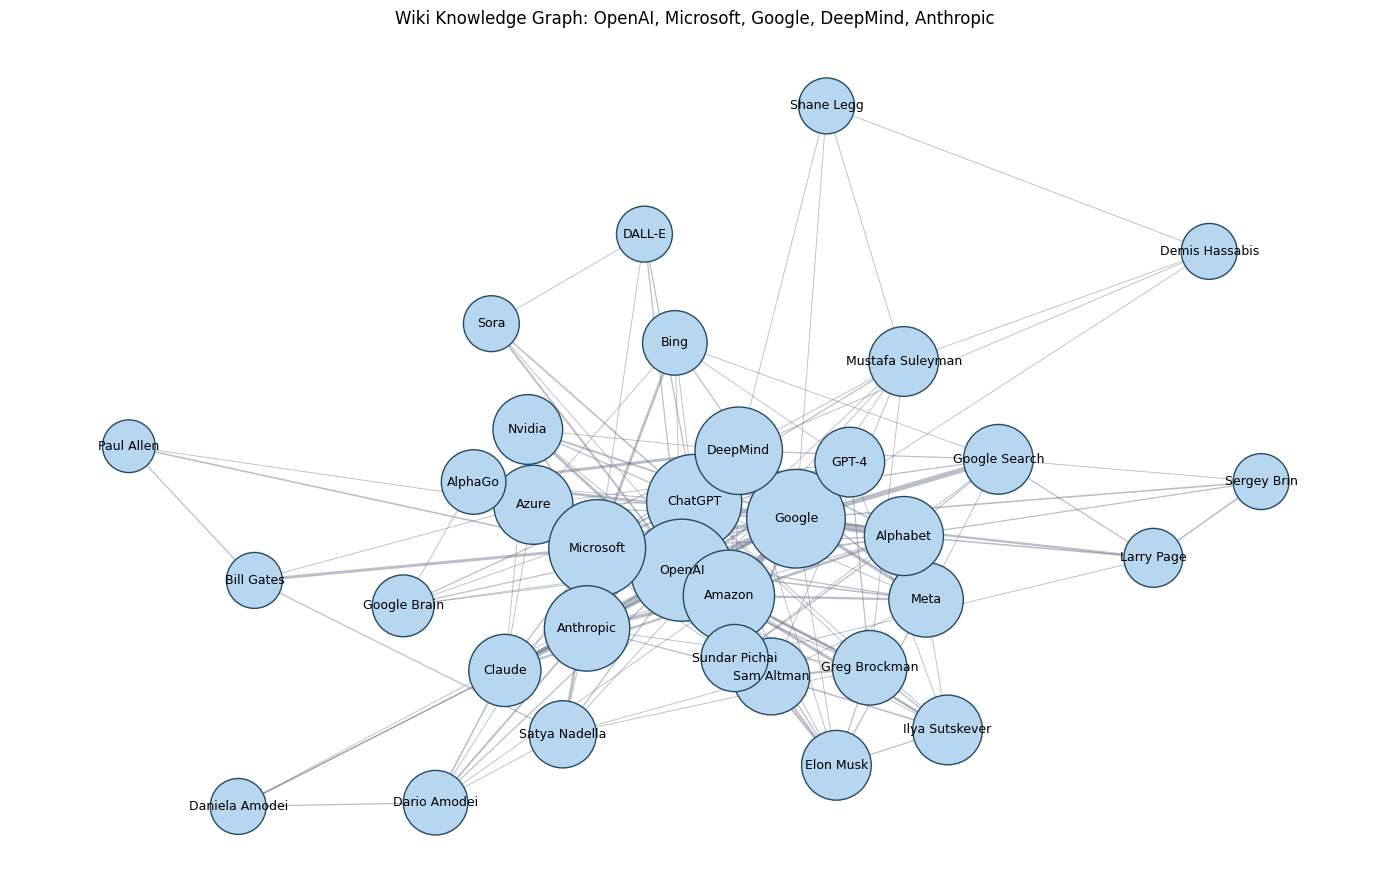

In [9]:
plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42, k=0.8)
node_sizes = [900 + 180 * G.degree(node) for node in G.nodes()]
edge_widths = [0.4 + 0.25 * G[u][v]["weight"] for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#B7D7F0", edgecolors="#244B66")
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.45, edge_color="#667085")
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Wiki Knowledge Graph: OpenAI, Microsoft, Google, DeepMind, Anthropic")
plt.axis("off")
plt.tight_layout()
plt.savefig("wiki_knowledge_graph.png", dpi=200, bbox_inches="tight")
plt.show()

## Step 9 - Implement GraphRAG Retrieval

The GraphRAG retrieval function follows this process:

1. Detect seed entities in the question.
2. Locate those entities in the knowledge graph.
3. Traverse the graph within a 2-hop neighborhood.
4. Rank graph edges connected to the seed entities.
5. Return graph relations and evidence chunks linked to those relations.

This approach retrieves context through entity relationships rather than only direct text similarity. It is especially useful for questions that require connecting multiple entities, such as `Microsoft -> OpenAI` or `Google -> DeepMind`.

Expected output: seed entities, graph edges, and supporting evidence chunks for a sample query.


In [10]:
chunk_by_id = {chunk["chunk_id"]: chunk for chunk in chunks}

def graph_rag(question, hops=2, max_evidence=5):
    seed_entities = find_entities(question)
    if not seed_entities:
        # Fallback: if the question has no known entity, use Flat RAG to guess a likely page.
        flat_top = flat_rag(question, top_k=1)[0]
        seed_entities = find_entities(flat_top["text"])

    selected_nodes = set(seed_entities)
    for seed in seed_entities:
        if seed in G:
            distances = nx.single_source_shortest_path_length(G, seed, cutoff=hops)
            selected_nodes.update(distances.keys())

    selected_edges = []
    for source, target, data in G.edges(data=True):
        if source in selected_nodes and target in selected_nodes:
            selected_edges.append({
                "source": source,
                "target": target,
                "weight": data["weight"],
                "relations": sorted(data["relations"]),
                "evidence": data["evidence"],
            })
    seed_set = set(seed_entities)
    selected_edges = sorted(
        selected_edges,
        key=lambda edge: (
            (edge["source"] in seed_set) and (edge["target"] in seed_set),
            (edge["source"] in seed_set) or (edge["target"] in seed_set),
            edge["weight"],
        ),
        reverse=True,
    )

    evidence_ids = []
    for edge in selected_edges:
        evidence_ids.extend(edge["evidence"])

    # Remove duplicate evidence while preserving order.
    seen = set()
    unique_evidence_ids = []
    for evidence_id in evidence_ids:
        if evidence_id not in seen:
            seen.add(evidence_id)
            unique_evidence_ids.append(evidence_id)

    evidence_chunks = [chunk_by_id[eid] for eid in unique_evidence_ids[:max_evidence] if eid in chunk_by_id]

    return {
        "question": question,
        "seed_entities": seed_entities,
        "nodes": sorted(selected_nodes),
        "edges": selected_edges,
        "evidence_chunks": evidence_chunks,
    }

def print_graph_rag(question, hops=2):
    result = graph_rag(question, hops=hops)
    print("QUESTION:", question)
    print("SEED ENTITIES:", result["seed_entities"])
    print("\nGRAPH EDGES:")
    for edge in result["edges"][:8]:
        rel = "/".join(edge["relations"])
        print(f"- {edge['source']} --[{rel}, weight={edge['weight']}]-- {edge['target']}")
    print("\nGRAPHRAG EVIDENCE:")
    for chunk in result["evidence_chunks"][:3]:
        snippet = textwrap.shorten(chunk["text"], width=420, placeholder="...")
        print(f"- {chunk['title']} | {chunk['chunk_id']}")
        print(snippet)
        print()

print_graph_rag("How are Microsoft and OpenAI connected?", hops=2)

QUESTION: How are Microsoft and OpenAI connected?
SEED ENTITIES: ['Microsoft', 'OpenAI']

GRAPH EDGES:
- OpenAI --[ACQUIRED_OR_OWNED/DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH, weight=24]-- Microsoft
- ChatGPT --[ACQUIRED_OR_OWNED/DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH, weight=27]-- OpenAI
- Azure --[ACQUIRED_OR_OWNED/DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH, weight=19]-- Microsoft
- OpenAI --[DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH, weight=16]-- Amazon
- OpenAI --[DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH, weight=13]-- Sam Altman
- OpenAI --[DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH, weight=12]-- Google
- OpenAI --[DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH, weight=12]-- Anthropic
- Amazon --[DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH, weight=10]-- Microsoft

GRAPHRAG EVIDENCE:
- OpenAI | Open

## Step 10 - Compare One Question Side by Side

This step prints Flat RAG evidence and GraphRAG context for the same question. The purpose is to make the retrieval behavior of both methods directly comparable.

Flat RAG returns the text chunks with the highest lexical similarity to the question. GraphRAG returns graph relations around the detected entities and then prints the evidence chunks associated with those graph edges.

Expected output: a side-by-side textual comparison for the question `How are Microsoft and OpenAI connected?`.


In [11]:
def compare_one_question(question):
    print("=" * 110)
    print("QUESTION:", question)
    print("=" * 110)
    print("\nFLAT RAG TOP EVIDENCE")
    print("-" * 110)
    for item in flat_rag(question, top_k=3):
        snippet = textwrap.shorten(item["text"], width=360, placeholder="...")
        print(f"[{item['rank']}] {item['title']} | score={item['score']}")
        print(snippet)
        print()

    graph_result = graph_rag(question, hops=2)
    print("\nGRAPHRAG GRAPH CONTEXT")
    print("-" * 110)
    print("Seed entities:", graph_result["seed_entities"])
    for edge in graph_result["edges"][:8]:
        rel = "/".join(edge["relations"])
        print(f"- {edge['source']} --[{rel}, weight={edge['weight']}]-- {edge['target']}")
    print("\nGRAPHRAG EVIDENCE")
    for chunk in graph_result["evidence_chunks"][:3]:
        snippet = textwrap.shorten(chunk["text"], width=360, placeholder="...")
        print(f"- {chunk['title']} | {chunk['chunk_id']}")
        print(snippet)
        print()

compare_one_question("How are Microsoft and OpenAI connected?")

QUESTION: How are Microsoft and OpenAI connected?

FLAT RAG TOP EVIDENCE
--------------------------------------------------------------------------------------------------------------
[1] OpenAI | score=0.1781
These investments were made at, a $29 billion valuation, double OpenAI's 2021 value. Later that year, Microsoft used OpenAI models for its Copilot chatbot, integrated Copilot into Windows, and released mobile apps for the service. Following OpenAI's 2025 restructuring, Microsoft owned a 27% stake in the for-profit OpenAI Group PBC, valued at $135 billion....

[2] OpenAI | score=0.1674
OpenAI stated that the capped-profit model would allow it to legally attract investment from venture funds and compensate employees with equity as competing AI companies did. Microsoft subsequently invested $1 billion in OpenAI LP, and OpenAI's services were migrated to Microsoft Azure. Since then, OpenAI systems have run on an Azure-based supercomputing...

[3] OpenAI | score=0.1669
In December 201

## Step 11 - Run a 20-Question Benchmark

The lab requires a benchmark comparison between Flat RAG and GraphRAG. This step defines 20 questions covering founders, products, acquisitions, partnerships, AI systems, and multi-entity relationships.

For each question, the notebook records:

- the top article selected by Flat RAG,
- the top Flat RAG similarity score,
- the top Flat RAG evidence snippet,
- the seed entities detected by GraphRAG,
- the strongest graph edges retrieved by GraphRAG.

Expected output: a benchmark dataframe that can be used directly in the final lab report.


In [12]:
BENCHMARK_QUESTIONS = [
    "Who founded OpenAI?",
    "How are Microsoft and OpenAI connected?",
    "Which company acquired DeepMind?",
    "How are Google and DeepMind connected?",
    "Who founded Google?",
    "Who founded Microsoft?",
    "Which organization created ChatGPT?",
    "Which organization created Claude?",
    "How is Anthropic related to OpenAI?",
    "Which company developed AlphaGo?",
    "How are Alphabet, Google, and DeepMind related?",
    "Which companies in this corpus are involved in artificial intelligence?",
    "What is the connection between Sam Altman and OpenAI?",
    "What is the connection between Demis Hassabis and DeepMind?",
    "What is the connection between Bill Gates and Microsoft?",
    "What is the connection between Larry Page and Google?",
    "Which companies are connected to cloud computing or Azure?",
    "Which organizations are connected to AI chatbots?",
    "Which company was founded earlier, Microsoft or Google?",
    "Which organizations in the corpus have relationships involving investment or partnership?",
]

def summarize_edges(edges, max_edges=5):
    lines = []
    for edge in edges[:max_edges]:
        rel = "/".join(edge["relations"])
        lines.append(f"{edge['source']} --{rel}-- {edge['target']}")
    return " | ".join(lines)

benchmark_rows = []
for question in BENCHMARK_QUESTIONS:
    flat_top = flat_rag(question, top_k=1)[0]
    graph_top = graph_rag(question, hops=2)
    benchmark_rows.append({
        "question": question,
        "flat_top_title": flat_top["title"],
        "flat_top_score": flat_top["score"],
        "flat_top_snippet": textwrap.shorten(flat_top["text"], width=220, placeholder="..."),
        "graph_seed_entities": ", ".join(graph_top["seed_entities"]),
        "graph_edges": summarize_edges(graph_top["edges"]),
    })

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df

,question,flat_top_title,flat_top_score,flat_top_snippet,graph_seed_entities,graph_edges
0,Who founded OpenAI?,OpenAI,0.2163,"In December 2016, OpenAI released ""Universe"", a software platform for measuring and training an AI's general intelligence across the wor...",OpenAI,ChatGPT --ACQUIRED_OR_OWNED/DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH-- OpenAI | OpenAI --ACQUIRED_OR_OWNED/DEVE...
1,How are Microsoft and OpenAI connected?,OpenAI,0.1781,"These investments were made at, a $29 billion valuation, double OpenAI's 2021 value. Later that year, Microsoft used OpenAI models for i...","Microsoft, OpenAI",OpenAI --ACQUIRED_OR_OWNED/DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH-- Microsoft | ChatGPT --ACQUIRED_OR_OWNED/D...
2,Which company acquired DeepMind?,Google DeepMind,0.1505,"DeepMind Technologies Limited, trading as Google DeepMind or simply DeepMind, is a British-American artificial intelligence (AI) researc...",DeepMind,Google --ACQUIRED_OR_OWNED/DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH-- DeepMind | DeepMind --ACQUIRED_OR_OWNED/D...
3,How are Google and DeepMind connected?,Google DeepMind,0.2175,"DeepMind Technologies Limited, trading as Google DeepMind or simply DeepMind, is a British-American artificial intelligence (AI) researc...","DeepMind, Google",Google --ACQUIRED_OR_OWNED/DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH-- DeepMind | Google --ACQUIRED_OR_OWNED/DEV...
4,Who founded Google?,Google,0.1780,"In a talk at Stanford University, Marissa Mayer, Google's vice-president of Search Products and User Experience until July 2012, showed ...",Google,Google --ACQUIRED_OR_OWNED/DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH-- DeepMind | Google --ACQUIRED_OR_OWNED/DEV...
5,Who founded Microsoft?,Microsoft,0.1561,"After the disruptions at these events, Microsoft contacted the FBI in search of assistance in surveilling its pro-Palestinian employees ...",Microsoft,OpenAI --ACQUIRED_OR_OWNED/DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH-- Microsoft | Azure --ACQUIRED_OR_OWNED/DEV...
6,Which organization created ChatGPT?,OpenAI,0.1673,"In April 2023, the EU's European Data Protection Board (EDPB) formed a dedicated task force on ChatGPT ""to foster cooperation and to exc...",ChatGPT,ChatGPT --ACQUIRED_OR_OWNED/DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH-- OpenAI | ChatGPT --ACQUIRED_OR_OWNED/DEV...
7,Which organization created Claude?,Anthropic,0.2015,"While Claude Code is tailored toward developers, Cowork is designed for non-technical users, enabling them to automate file and task man...",Claude,Anthropic --ACQUIRED_OR_OWNED/DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH-- Claude | OpenAI --DEVELOPED/FOUNDED_OR...
8,How is Anthropic related to OpenAI?,Anthropic,0.1950,"The hackers bypassed Anthropic's safeguards by pretending it was for defensive testing. In December 2025, Anthropic acquired Bun to impr...","Anthropic, OpenAI",OpenAI --DEVELOPED/FOUNDED_OR_CREATED/INVESTED_OR_PARTNERED/MENTIONED_WITH-- Anthropic | ChatGPT --ACQUIRED_OR_OWNED/DEVELOPED/FOUNDED_O...
9,Which company developed AlphaGo?,Google DeepMind,0.2353,"AlphaGo Zero employed around 15 people and millions in computing resources. Ultimately, it needed much less computing power than AlphaGo...",AlphaGo,DeepMind --ACQUIRED_OR_OWNED/DEVELOPED/MENTIONED_WITH-- AlphaGo | Google --ACQUIRED_OR_OWNED/DEVELOPED/MENTIONED_WITH-- AlphaGo | ChatGP...


## Step 12 - Export Benchmark Results

This step exports the benchmark dataframe to `wiki_flat_vs_graphrag_benchmark.csv`. The CSV file can be opened in Excel or included as a table in the final report.

Expected output: confirmation that both the benchmark CSV and graph image have been saved.


In [13]:
benchmark_df.to_csv("wiki_flat_vs_graphrag_benchmark.csv", index=False, encoding="utf-8-sig")
print("Saved: wiki_flat_vs_graphrag_benchmark.csv")
print("Saved: wiki_knowledge_graph.png")

Saved: wiki_flat_vs_graphrag_benchmark.csv
Saved: wiki_knowledge_graph.png


## Final Analysis

This experiment implements a simple but complete comparison between Flat RAG and GraphRAG on a small Wikipedia corpus.

- **Flat RAG** is fast, simple, and effective for questions where the answer appears clearly in one retrieved passage. However, it relies mainly on lexical similarity and may miss relationships that are distributed across multiple chunks.
- **GraphRAG** provides an explicit entity-relation structure. It is more interpretable for multi-hop questions because the retrieved context includes graph edges such as `Microsoft -> OpenAI` and `Google -> DeepMind`.
- The current graph construction method is rule-based. This keeps the experiment reproducible and avoids LLM token cost, but relation labels may be noisy because they are inferred from keyword matches and co-occurrence.
- The token cost of graph construction in this version is zero because no LLM is used. The main computational cost comes from downloading Wikipedia pages, building the TF-IDF matrix, constructing the NetworkX graph, and running benchmark retrieval.

Overall, the Flat RAG baseline is useful as a fast retrieval reference, while the GraphRAG prototype demonstrates how entity connections can improve interpretability and support relationship-based queries.
